# Module 02 - Exploratory Data Analysis

**Mục tiêu.** Notebook này không chỉ vẽ thống kê mô tả. Mỗi phần
đều đi theo logic: đặt câu hỏi vận hành, chọn phép phân tích, đọc
kết quả, rồi chuyển insight thành quyết định cho mô hình/DSS.

**Nguyên tắc đọc.**

1. Các cột sau giao hàng được dùng để hiểu dữ liệu, không dùng làm
   feature dự báo.
2. `location` có dạng "City, ST"; `state_code` trong notebook được
   suy ra từ chuỗi này, không phải cột bang chính thức.
3. Vì dữ liệu có dấu hiệu synthetic, insight được dùng cho báo cáo
   học thuật và dashboard, không kết luận nhân quả kinh doanh.

> **Đối tượng & cách đọc.** Notebook cho **người mới** trong nhóm. Lời
> giải thích bằng tiếng Việt; thuật ngữ tiếng Anh (F2, MCC, bootstrap…)
> được định nghĩa ở mục **"0. Định nghĩa"** và đầy đủ trong
> `docs/GLOSSARY.md`. Mỗi mục theo mạch *mục tiêu → phân tích → insight*;
> mỗi bảng/biểu đồ có **một dòng đọc-hiểu ngay bên dưới**.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
from IPython.display import Image
from pizza_dss.business_analysis import customer_preference_tables, hypothesis_tests
from pizza_dss.data_loader import audit_dataset, load_dataset
from pizza_dss.eda import (
    add_distance_band,
    add_location_parts,
    association_rules_to_delay,
    build_eda_artifacts,
    delay_rate_by,
    delay_rate_with_ci,
    kmeans_cluster_profile,
    delay_severity_distribution,
    duration_delay_profile,
    duration_grid_by_delay,
    favorite_item_summary,
    kmeans_silhouette_sweep,
    location_dependency_summary,
    restaurant_dependency_summary,
    restaurant_mix_matrix,
    state_dependency_summary,
    state_mix_matrix,
)

**Sinh trước các hình.** Cell dưới tạo toàn bộ PNG dùng chung cho
notebook, slide và báo cáo, để các mục sau hiển thị biểu đồ inline.

In [2]:
_ = build_eda_artifacts()

## 0. Định nghĩa thuật ngữ EDA

- **Delay rate** = tỷ lệ đơn trễ trong một nhóm.
- **Khoảng tin cậy Wilson (95%)**: dải giá trị hợp lý của delay rate khi
  nhóm ít đơn; ưu tiên hơn xấp xỉ chuẩn vì không vỡ ở tỷ lệ cực đoan/n
  nhỏ. Hai nhóm có CI chồng nhau ⇒ chưa đủ bằng chứng khác biệt.
- **Chi-square độc lập**: kiểm định biến phân loại có liên hệ với nhãn
  trễ không; `p < 0.05` = có bằng chứng liên hệ.
- **Cramér's V**: độ mạnh liên hệ trong [0,1]; quy ước thô: <0.1 không
  đáng kể, 0.1-0.3 yếu, 0.3-0.5 vừa, >0.5 mạnh.
- **Silhouette**: chất lượng phân cụm trong [-1,1]; cao = cụm tách tốt.
- **Association rule**: `support` = tần suất xuất hiện chung; `confidence`
  = P(trễ | điều kiện); `lift` = confidence / tỷ lệ trễ chung (>1 = điều
  kiện làm tăng khả năng trễ).

## 1. Load dữ liệu và câu hỏi EDA

Trước khi modeling, cần hiểu dữ liệu trả lời được gì:

- Tỷ lệ trễ và mức độ trễ phân bố như thế nào?
- Traffic, distance, complexity, size/type liên quan gì đến trễ?
- Món/size nào được đặt nhiều nhất?
- Sở thích có khác theo restaurant, location hoặc state suy ra không?
- Insight nào đủ an toàn để đưa vào DSS, dashboard hoặc feature set?

In [3]:
df = add_location_parts(add_distance_band(load_dataset()))
audit_dataset(df)

{'rows': 1004,
 'columns': 39,
 'missing_total': 0,
 'duplicate_order_ids': 0,
 'date_min': '2024-01-05 18:30:00',
 'date_max': '2026-07-07 20:00:00',
 'years': {'2024': 443, '2025': 373, '2026': 188},
 'target_distribution': {'False': 794, 'True': 210},
 'delayed_rate': 0.2092,
 'is_delayed_equals_duration_gt_30': True,
 'max_delay_formula_error': 0.0,
 'chronological_last20_rows': 201,
 'chronological_last20_delayed': 0,
 'feature_columns': ['toppings_count',
  'distance_km',
  'topping_density',
  'estimated_duration_min',
  'pizza_complexity',
  'traffic_impact',
  'order_hour',
  'restaurant_name',
  'location',
  'pizza_size',
  'pizza_type',
  'traffic_level',
  'payment_method',
  'is_peak_hour',
  'is_weekend',
  'order_month',
  'payment_category'],
 'blocked_leakage_columns': ['delivery_time',
  'delivery_duration_min',
  'delivery_efficiency_min_per_km',
  'delay_min',
  'restaurant_avg_time']}

In [4]:
df.head()

,order_id,restaurant_name,location,order_time,delivery_time,delivery_duration_min,pizza_size,pizza_type,toppings_count,distance_km,...,pizza_size_code,pizza_size_label,order_period,order_weekday,order_weekday_name,time_segment,complexity_band,distance_band,city,state_code
0,ORD001,Domino's,"New York, NY",2024-01-05 18:30:00,2024-01-05 18:45:00,15,Medium,Veg,3,2.5,...,02,02_Medium,2024-01,4,Friday,Dinner,Medium,0-3 km,New York,NY
1,ORD002,Papa John's,"Los Angeles, CA",2024-02-14 20:00:00,2024-02-14 20:25:00,25,Large,Non-Veg,4,5.0,...,03,03_Large,2024-02,2,Wednesday,Dinner,High,3-6 km,Los Angeles,CA
2,ORD003,Little Caesars,"Chicago, IL",2024-03-21 12:15:00,2024-03-21 12:35:00,20,Small,Vegan,2,3.0,...,01,01_Small,2024-03,3,Thursday,Lunch,Low,0-3 km,Chicago,IL
3,ORD004,Pizza Hut,"Miami, FL",2024-04-10 19:45:00,2024-04-10 20:10:00,25,XL,Cheese Burst,5,4.5,...,04,04_XL,2024-04,2,Wednesday,Dinner,Very High,3-6 km,Miami,FL
4,ORD005,Marco's Pizza,"Dallas, TX",2024-05-05 13:00:00,2024-05-05 13:20:00,20,Medium,Non-Veg,3,2.0,...,02,02_Medium,2024-05,6,Sunday,Lunch,Medium,0-3 km,Dallas,TX


## 2. Phân tích nhãn và độ trễ

**Lý do làm.** Nếu chỉ biết `is_delayed`, ta chưa biết độ trễ nặng
hay nhẹ. Vì vậy phần này xem duration, estimated duration và
`delay_min` như biến chẩn đoán hậu nghiệm để hiểu generator và mức
độ rủi ro. Những cột này không được dùng trong mô hình dự báo.

In [5]:
duration_delay_profile(df).round(3)

,is_delayed,orders,duration_min,duration_q25,duration_median,duration_mean,duration_q75,duration_max,estimated_duration_mean,delay_min_mean,delay_min_median,distance_mean,complexity_mean,high_traffic_share,peak_hour_share
0,False,794,15,20.0,30.0,26.272,30.0,30,10.078,16.194,15.6,4.199,8.288,0.205,0.932
1,True,210,35,40.0,40.0,41.667,45.0,50,18.642,23.024,22.0,7.768,13.929,0.786,0.995


In [6]:
duration_grid_by_delay(df).round(3)

,delivery_duration_min,orders,delayed,delay_rate,avg_distance_km,avg_estimated_duration_min,avg_delay_min,on_time,minutes_over_30_boundary
0,15,1,0,0.0,2.500,6.000,9.000,1,-15
1,20,233,0,0.0,2.953,7.087,12.913,233,-10
2,25,123,0,0.0,3.720,8.929,16.071,123,-5
3,30,437,0,0.0,5.003,12.006,17.994,437,0
4,35,44,44,1.0,5.520,13.249,21.751,0,5
5,40,92,92,1.0,7.566,18.159,21.841,0,10
6,45,34,34,1.0,8.682,20.838,24.162,0,15
7,50,40,40,1.0,9.925,23.820,26.180,0,20


In [7]:
delay_severity_distribution(df).round(3)

,delay_severity,orders,delayed,order_share,avg_distance_km,avg_complexity,high_traffic_share
0,On-time <=30,794,0,0.791,4.199,8.288,0.205
1,Late 35,44,44,0.044,5.520,6.659,0.091
2,Late 40,92,92,0.092,7.566,18.826,0.978
3,Late 45-50,74,74,0.074,9.354,12.162,0.959


**Insight.** Nhóm on-time có duration tối đa 30 phút, nhóm delayed
có duration tối thiểu 35 phút. Duration chỉ nhận các giá trị bội số
5 nên ranh giới nhãn nằm giữa 30 và 35 phút. Điều này dẫn tới quyết
định chống leakage: duration/delay chỉ dùng để audit, không đưa vào
feature dự báo.

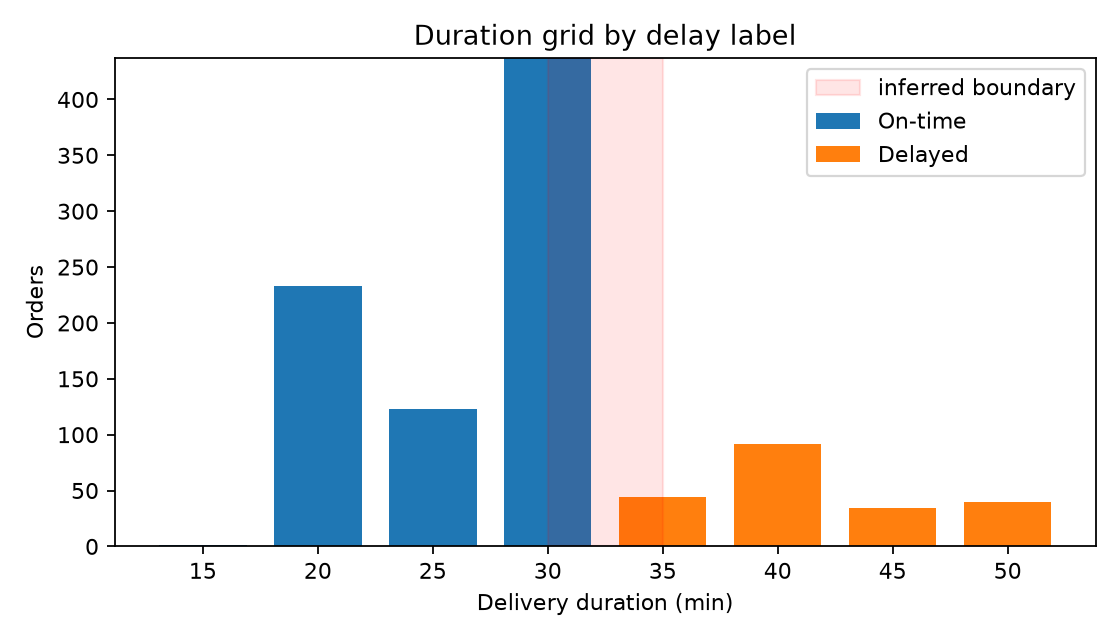

In [8]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "duration_grid_by_delay.png"))

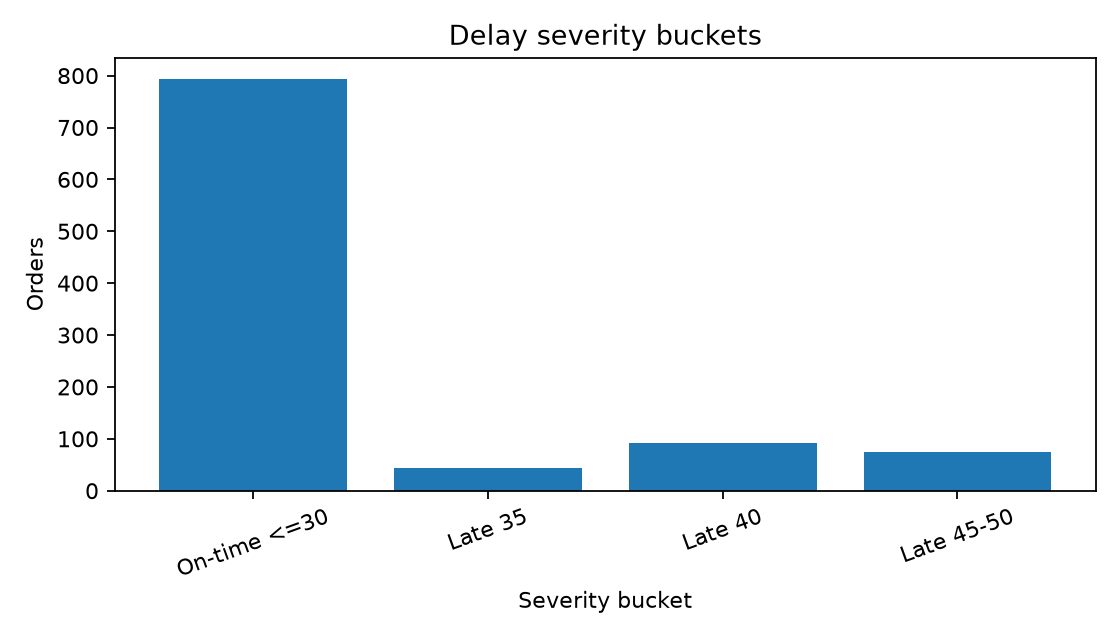

In [9]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "delay_severity_distribution.png"))

## 3. Delay rate theo yếu tố vận hành

**Vì sao bước này?**
- Làm gì: Tính toán Delay Rate (tỷ lệ trễ) theo từng biến phân loại (traffic, distance, complexity, order_hour) và đính kèm Khoảng tin cậy Wilson (Wilson CI).
- Vì sao: 
  - Khách hàng/Business thường hỏi "Đơn xa thì trễ nhiều hơn không?", bảng này trả lời trực tiếp câu hỏi đó. 
  - Dùng **Wilson CI** thay vì xấp xỉ chuẩn (Normal Approximation) vì có những nhóm rất nhỏ (ví dụ: giờ khuya, hoặc traffic đặc biệt). Xấp xỉ chuẩn có thể sinh ra CI < 0 hoặc > 1 (vô lý với tỷ lệ), trong khi Wilson CI đáng tin cậy hơn cho tỷ lệ mẫu nhỏ hoặc cực đoan.
- Kỹ thuật: Groupby Aggregation, Proportion Confidence Interval (Wilson Score Interval).
- Bằng chứng dẫn tới: Nhiều phân khúc (ví dụ: distance 8+ km) có lượng sample khá nhỏ, cần một thước đo chắc chắn để tránh kết luận sai lầm về nguyên nhân gây trễ.

In [10]:
delay_rate_by(df, "traffic_level").round(4)

,traffic_level,count,delayed,delay_rate
0,High,328,165,0.5030
1,Medium,398,44,0.1106
2,Low,278,1,0.0036


In [11]:
delay_rate_by(df, "distance_band").round(4)

,distance_band,count,delayed,delay_rate
0,8+ km,68,68,1.0000
1,6-8 km,100,96,0.9600
2,3-6 km,623,46,0.0738
3,0-3 km,213,0,0.0000


In [12]:
delay_rate_by(df, "complexity_band").round(4)

,complexity_band,count,delayed,delay_rate
0,Very High,204,85,0.4167
1,High,238,83,0.3487
2,Medium,320,38,0.1188
3,Low,242,4,0.0165


In [13]:
delay_rate_by(df, "order_hour").round(4)

,order_hour,count,delayed,delay_rate
0,20,306,109,0.3562
1,21,3,1,0.3333
2,19,328,88,0.2683
3,17,4,1,0.2500
4,18,312,11,0.0353
5,14,6,0,0.0000
6,12,2,0,0.0000
7,13,43,0,0.0000


**Delay rate kèm khoảng tin cậy Wilson** (đọc kèm `orders` để không tin nhóm nhỏ):

In [14]:
pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "delay_rate_ci_by_distance_band.csv").round(4)

,distance_band,orders,delayed,delay_rate,ci_low,ci_high,small_sample
0,8+ km,68,68,1.0000,0.9465,1.0000,False
1,6-8 km,100,96,0.9600,0.9016,0.9843,False
2,3-6 km,623,46,0.0738,0.0558,0.0971,False
3,0-3 km,213,0,0.0000,0.0000,0.0177,False


In [15]:
pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "delay_rate_ci_by_traffic_level.csv").round(4)

,traffic_level,orders,delayed,delay_rate,ci_low,ci_high,small_sample
0,High,328,165,0.5030,0.4492,0.5568,False
1,Medium,398,44,0.1106,0.0834,0.1452,False
2,Low,278,1,0.0036,0.0006,0.0201,False


**Insight (bảng CI).** Delay rate tăng đơn điệu theo distance band và
theo mức traffic, và các CI **không chồng nhau** giữa nhóm thấp/cao →
khác biệt là thật chứ không phải nhiễu mẫu. Nhóm nào `small_sample=True`
thì đọc thận trọng.

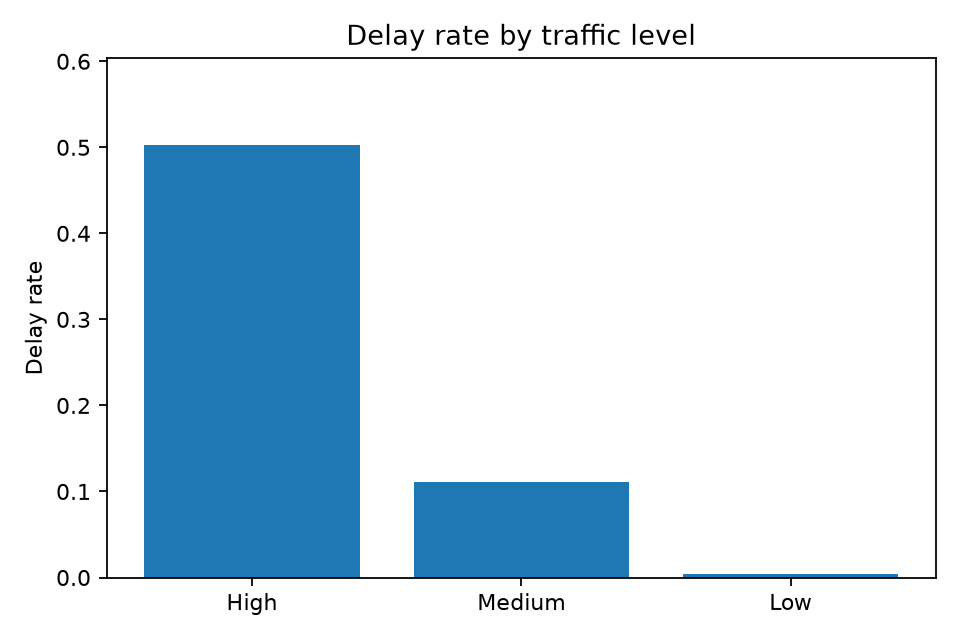

In [16]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "delay_rate_by_traffic.png"))

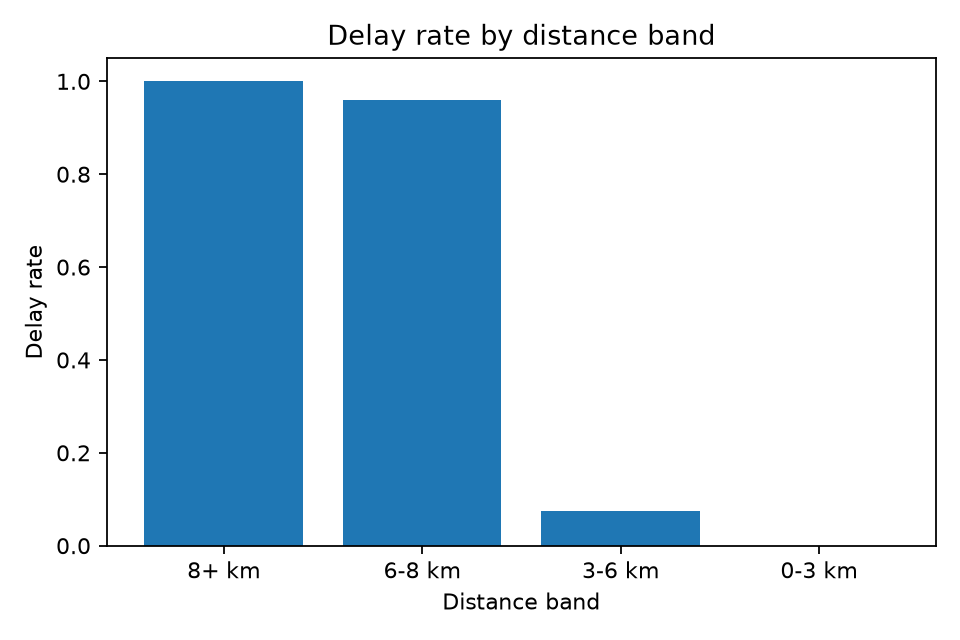

In [17]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "delay_rate_by_distance_band.png"))

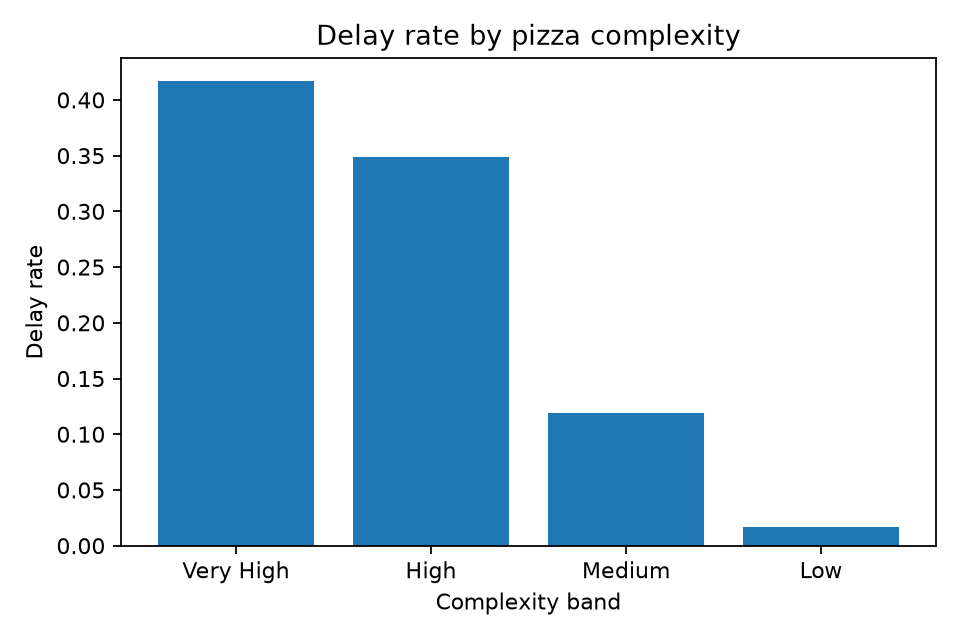

In [18]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "delay_rate_by_complexity_band.png"))

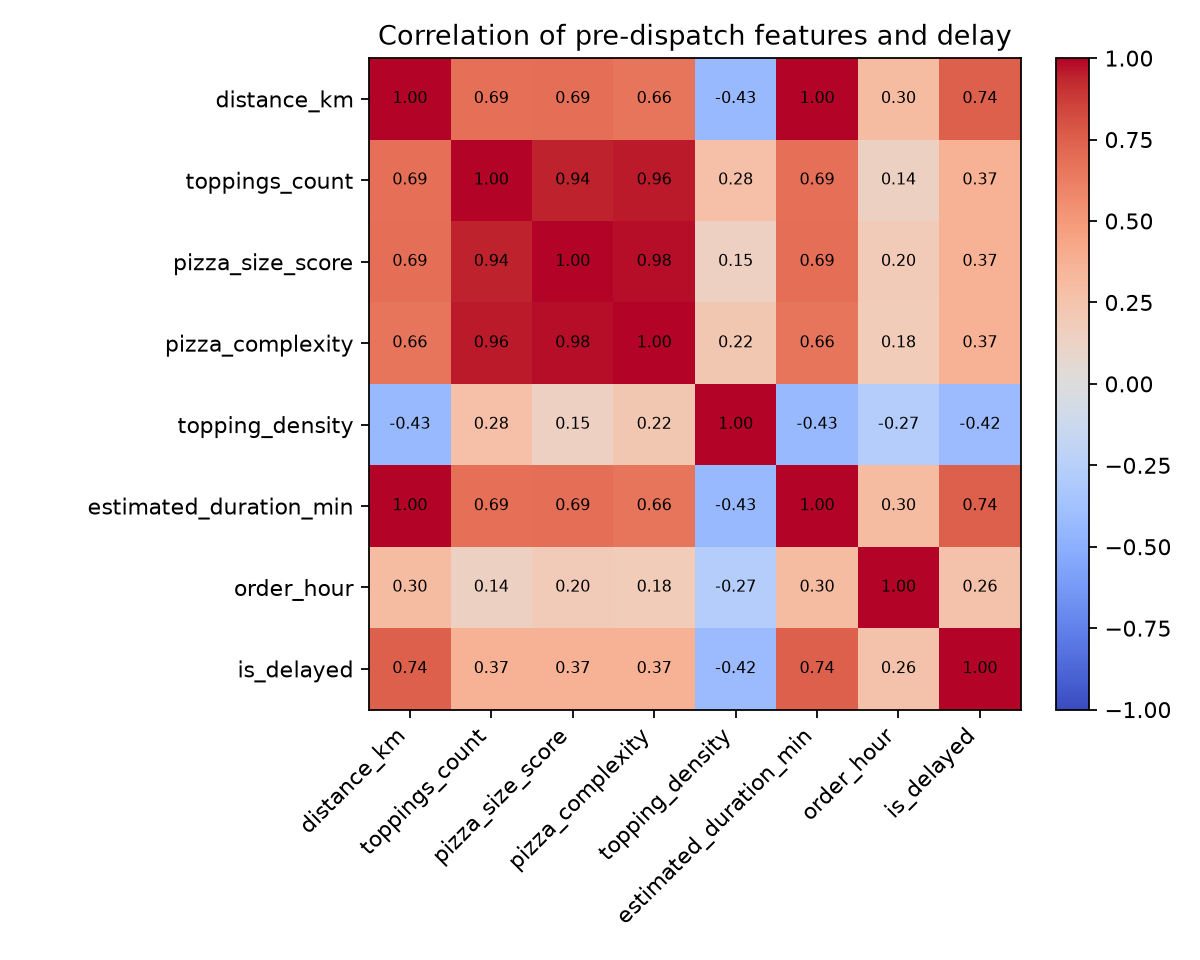

In [19]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "correlation_heatmap.png"))

**Insight.** Traffic, distance và một phần complexity làm thay đổi
delay rate rõ hơn payment/weekend. Vì vậy các biến này được ưu tiên
trong mô hình và công thức Risk Score. Heatmap tương quan cho thấy
`distance_km` và `estimated_duration_min` gần như trùng nhau (chứng
cứ redundancy), nên compact feature set chỉ giữ một biến đại diện.

## 4. Món yêu thích và preference

**Lý do làm.** DSS không chỉ dự báo trễ. Quản lý còn cần biết cơ cấu
nhu cầu: loại pizza nào bán nhiều, size nào phổ biến, combo nào vừa
phổ biến vừa rủi ro. Phần này phục vụ dashboard, Power BI và
recommendation rule.

In [20]:
favorites = favorite_item_summary(df)
favorites.query("dimension == 'pizza_type'").round(4)

,dimension,key,orders,order_share,delayed,delay_rate,avg_duration_min
0,pizza_type,Non-Veg,216,0.2151,45,0.2083,29.9769
1,pizza_type,Veg,202,0.2012,44,0.2178,28.7624
2,pizza_type,Cheese Burst,188,0.1873,67,0.3564,32.2606
3,pizza_type,Vegan,132,0.1315,3,0.0227,22.0076
4,pizza_type,Sicilian,64,0.0637,6,0.0938,30.8594
5,pizza_type,Margarita,54,0.0538,0,0.0000,30.0000
6,pizza_type,BBQ Chicken,54,0.0538,0,0.0000,30.0000
7,pizza_type,Gluten-Free,41,0.0408,22,0.5366,32.4390
8,pizza_type,Thai Chicken,24,0.0239,3,0.1250,31.6667
9,pizza_type,Stuffed Crust,21,0.0209,20,0.9524,39.5238


In [21]:
favorites.query("dimension == 'pizza_size'").round(4)

,dimension,key,orders,order_share,delayed,delay_rate,avg_duration_min
12,pizza_size,02_Medium | Medium,429,0.4273,39,0.0909,27.5291
13,pizza_size,03_Large | Large,240,0.2390,85,0.3542,34.1667
14,pizza_size,04_XL | XL,203,0.2022,84,0.4138,33.0788
15,pizza_size,01_Small | Small,132,0.1315,2,0.0152,21.8561


In [22]:
favorites.query("dimension == 'type_size_combo'").head(15).round(4)

,dimension,key,orders,order_share,delayed,delay_rate,avg_duration_min
16,type_size_combo,Cheese Burst | 04_XL,180,0.1793,61,0.3389,32.1111
17,type_size_combo,Non-Veg | 02_Medium,136,0.1355,1,0.0074,23.8603
18,type_size_combo,Vegan | 01_Small,130,0.1295,2,0.0154,21.7692
19,type_size_combo,Veg | 02_Medium,118,0.1175,13,0.1102,27.1610
20,type_size_combo,Veg | 03_Large,84,0.0837,31,0.3690,31.0119
21,type_size_combo,Non-Veg | 03_Large,78,0.0777,42,0.5385,40.2564
22,type_size_combo,Sicilian | 03_Large,60,0.0598,2,0.0333,30.2500
23,type_size_combo,BBQ Chicken | 02_Medium,54,0.0538,0,0.0000,30.0000
24,type_size_combo,Margarita | 02_Medium,54,0.0538,0,0.0000,30.0000
25,type_size_combo,Gluten-Free | 02_Medium,41,0.0408,22,0.5366,32.4390


In [23]:
prefs = customer_preference_tables(df)
prefs["type_size_matrix"]

pizza_size_label,pizza_type,01_Small,02_Medium,03_Large,04_XL
0,BBQ Chicken,0,54,0,0
1,Cheese Burst,0,0,8,180
2,Deep Dish,0,0,6,0
3,Gluten-Free,0,41,0,0
4,Margarita,0,54,0,0
5,Non-Veg,0,136,78,2
6,Sicilian,0,3,60,1
7,Stuffed Crust,0,1,1,19
8,Thai Chicken,2,19,3,0
9,Thin Crust,0,2,0,0


**Insight.** Medium là size phổ biến nhất và có delay rate thấp hơn
Large/XL. Non-Veg là type có số đơn cao nhất, còn Cheese Burst và
một vài nhóm nhỏ có delay rate cao hơn. Vì nhiều nhóm nhỏ rất sparse,
các tỷ lệ cực đoan chỉ dùng để cảnh báo/khám phá, không kết luận thị
hiếu thật.

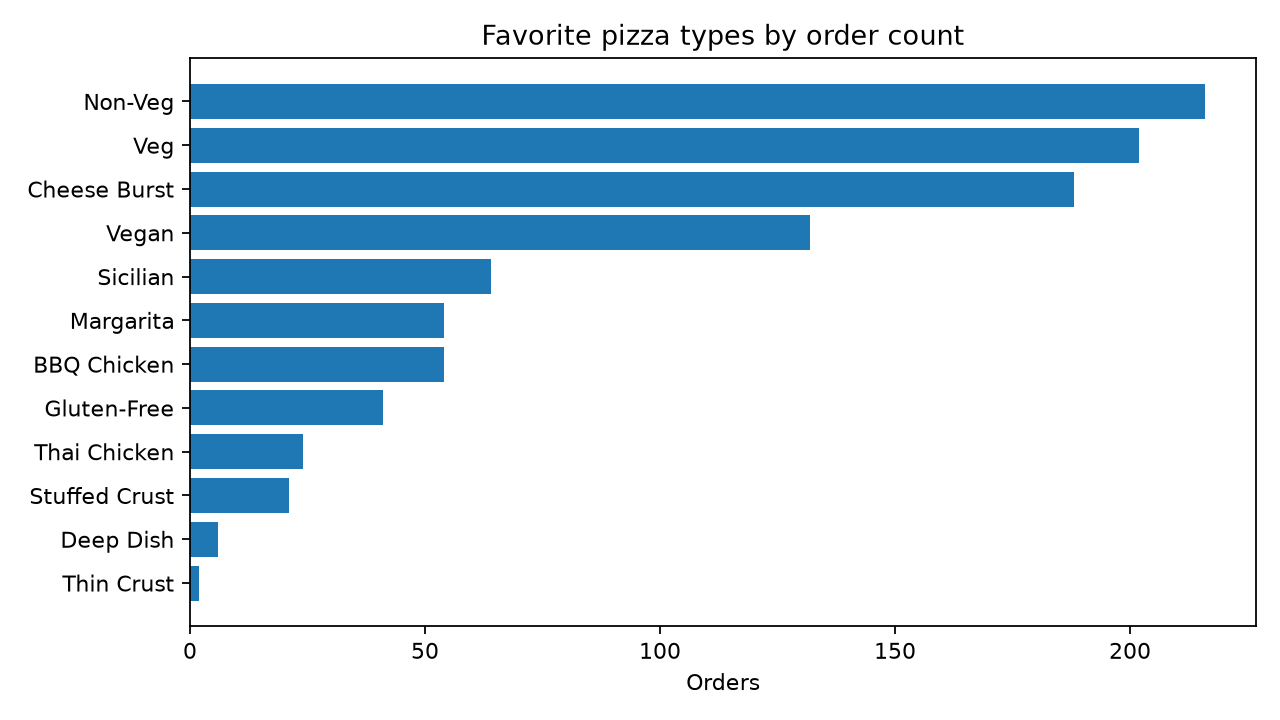

In [24]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "top_pizza_types.png"))

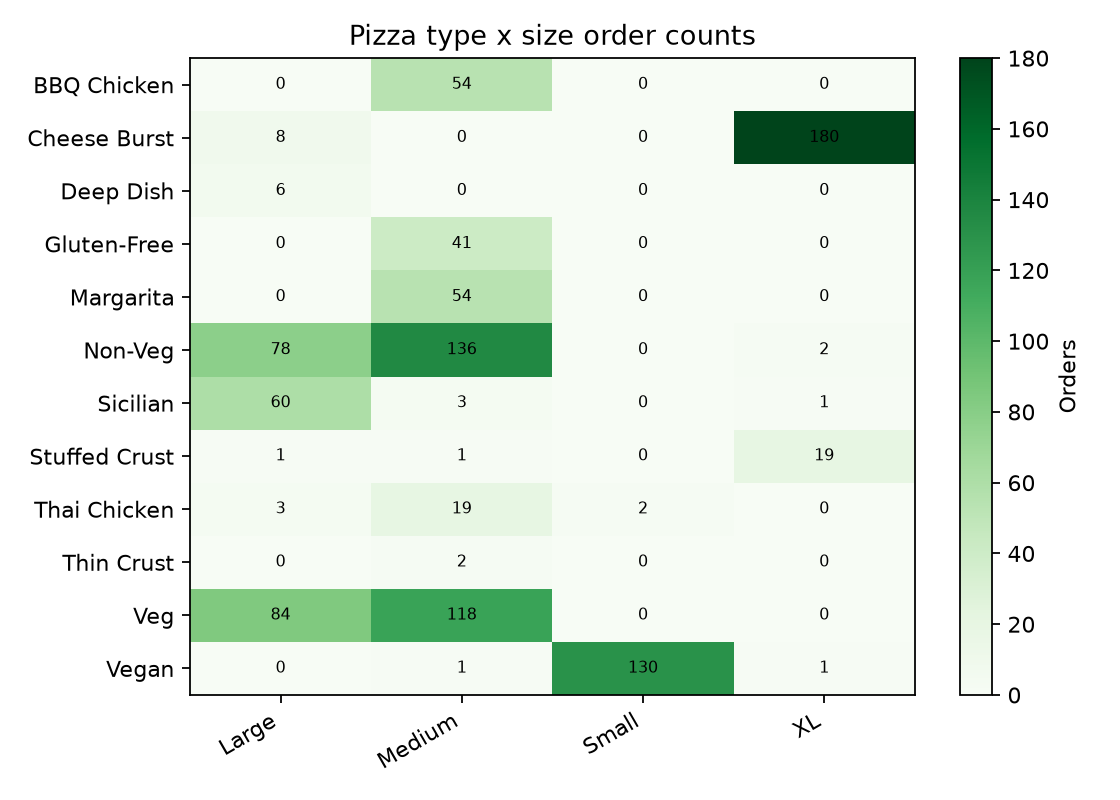

In [25]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "pizza_type_size_heatmap.png"))

## 5. Phụ thuộc theo restaurant/brand

In [26]:
restaurant_dependency_summary(df).round(4)

,restaurant_name,orders,delayed,delay_rate,avg_duration_min,avg_distance_km,avg_complexity,high_traffic_share,peak_hour_share,weekend_share,online_payment_share,top_type,top_type_orders,top_size,top_size_orders,top_location,top_location_orders
0,Domino's,212,62,0.2925,30.2594,5.5156,10.3066,0.3113,0.9953,0.3066,0.7358,Veg,106,Large,160,"Albuquerque, NM",56
3,Papa John's,204,26,0.1275,28.1863,4.2912,5.8873,0.1324,0.9902,0.2794,0.8873,BBQ Chicken,54,Medium,129,"Omaha, NE",67
1,Little Caesars,199,45,0.2261,28.8442,5.0930,12.7085,0.6231,0.9899,0.2563,0.8291,Cheese Burst,93,XL,110,"Louisville, KY",67
2,Marco's Pizza,195,36,0.1846,30.2308,4.9149,6.7026,0.2718,0.7487,0.2769,0.5179,Non-Veg,88,Medium,142,"Milwaukee, WI",67
4,Pizza Hut,194,41,0.2113,29.9485,4.8907,11.7732,0.2990,0.9948,0.3041,0.7835,Cheese Burst,83,XL,88,"Atlanta, GA",58


In [27]:
restaurant_mix_matrix(df, "pizza_type").round(4)

pizza_type,restaurant_name,orders,BBQ Chicken,Cheese Burst,Deep Dish,Gluten-Free,Margarita,Non-Veg,Sicilian,Stuffed Crust,Thai Chicken,Thin Crust,Veg,Vegan
0,Domino's,212,0.0000,0.0472,0.0094,0.0189,0.0000,0.1132,0.2783,0.0000,0.0142,0.0094,0.5000,0.0094
1,Little Caesars,199,0.0000,0.4673,0.0000,0.0000,0.0000,0.2362,0.0050,0.0653,0.0050,0.0000,0.0000,0.2211
2,Marco's Pizza,195,0.0000,0.0000,0.0000,0.0000,0.2769,0.4513,0.0051,0.0000,0.1026,0.0000,0.0821,0.0821
3,Papa John's,204,0.2647,0.0098,0.0196,0.1814,0.0000,0.2010,0.0147,0.0000,0.0000,0.0000,0.0784,0.2304
4,Pizza Hut,194,0.0000,0.4278,0.0000,0.0000,0.0000,0.0825,0.0000,0.0412,0.0000,0.0000,0.3299,0.1186


In [28]:
restaurant_mix_matrix(df, "pizza_size").round(4)

pizza_size,restaurant_name,orders,Large,Medium,Small,XL
0,Domino's,212,0.7547,0.2217,0.0094,0.0142
1,Little Caesars,199,0.0000,0.2312,0.2161,0.5528
2,Marco's Pizza,195,0.1846,0.7282,0.0872,0.0000
3,Papa John's,204,0.1275,0.6324,0.2304,0.0098
4,Pizza Hut,194,0.0928,0.3351,0.1186,0.4536


**Insight.** Brand không chỉ khác nhau ở count; mỗi restaurant có
mix type/size, distance và traffic khác nhau. Vì vậy có thể phân
tích brand cho dashboard, nhưng không kết luận "hãng tốt/xấu" nếu
không có bằng chứng dữ liệu vận hành thật.

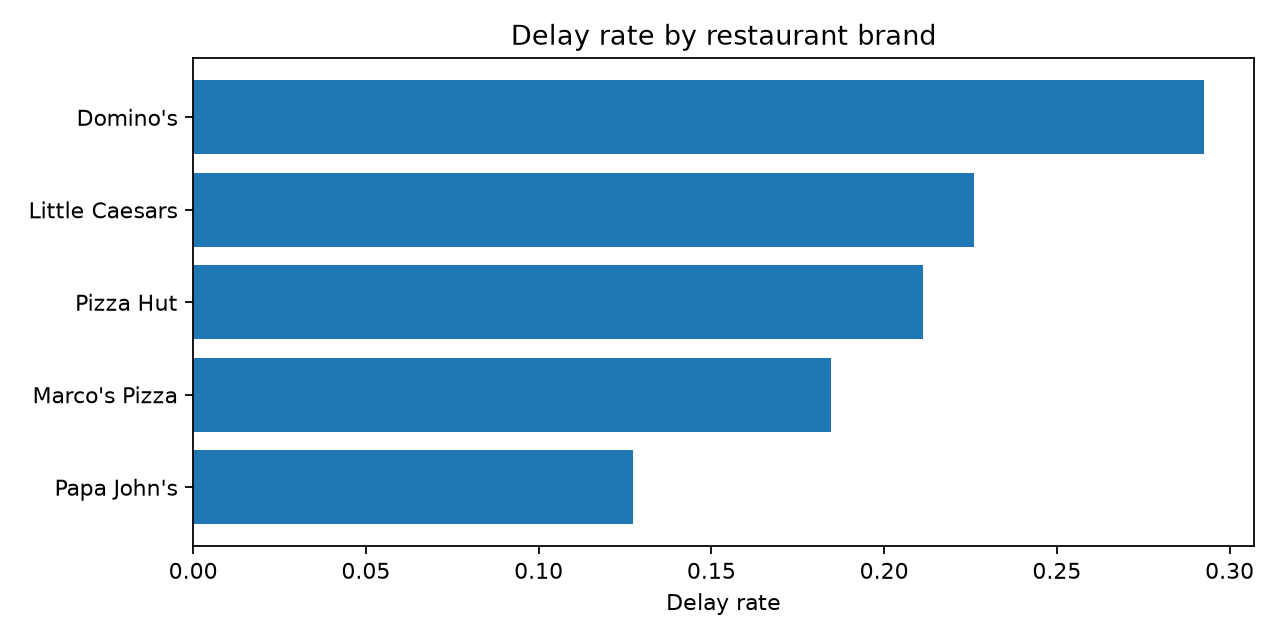

In [29]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "restaurant_delay_rate.png"))

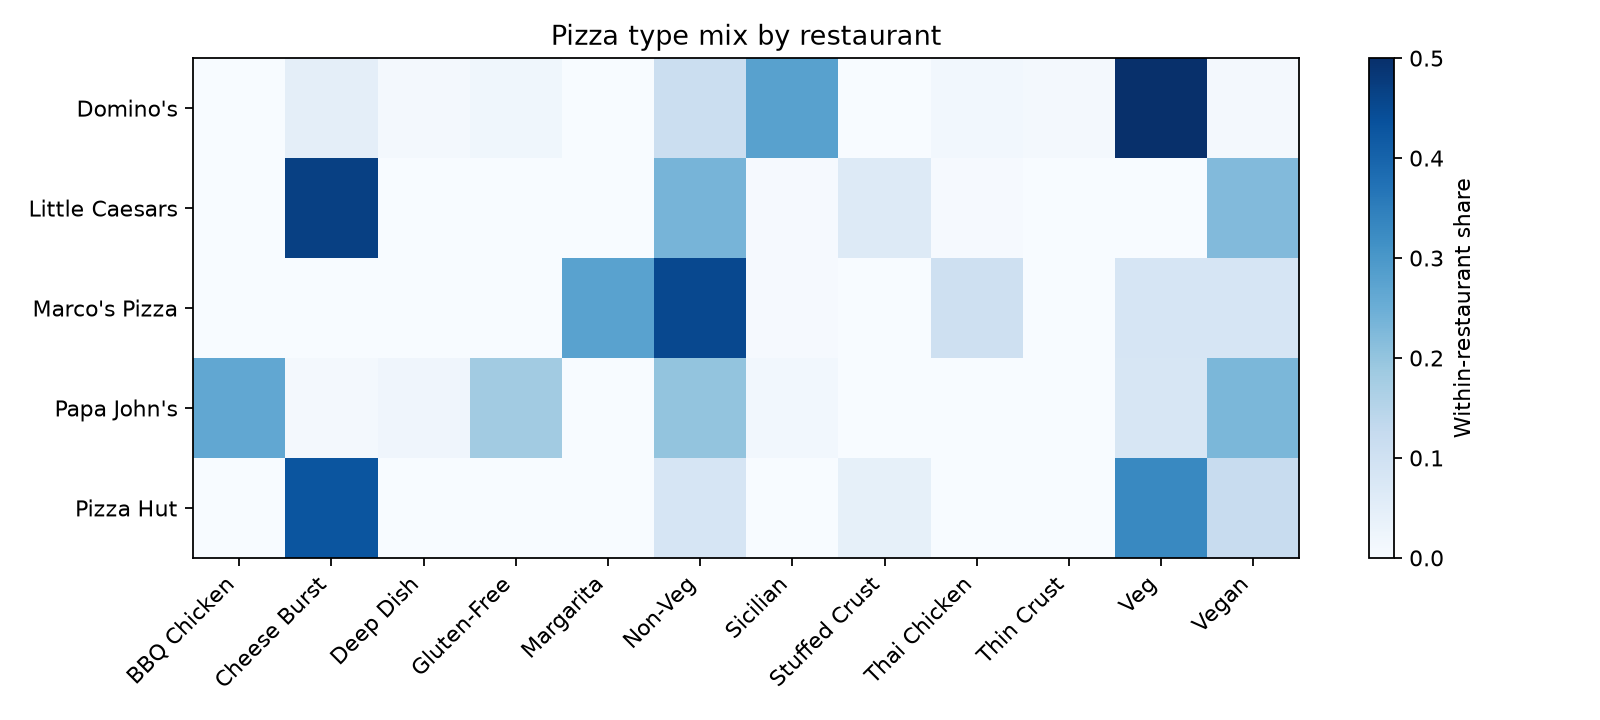

In [30]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "restaurant_pizza_type_mix_heatmap.png"))

## 6. Phụ thuộc theo location và state suy ra

**Lý do làm.** User vận hành thường hỏi khu vực nào nhiều rủi ro.
Dataset không có cột bang chính thức, nhưng `location` chứa dạng
"City, ST", nên notebook suy ra `state_code` để phân tích mô tả.
Những nhóm ít đơn được gắn cờ small sample.

In [31]:
location_dependency_summary(df).head(25).round(4)

,state_code,city,location,orders,delayed,delay_rate,avg_duration_min,avg_distance_km,high_traffic_share,peak_hour_share,top_restaurant,top_restaurant_orders,top_type,top_type_orders,top_size,top_size_orders,small_sample_flag
27,GA,Atlanta,"Atlanta, GA",78,4,0.0513,28.7821,4.0154,0.0641,0.8846,Pizza Hut,58,Veg,56,Medium,66,False
83,WI,Milwaukee,"Milwaukee, WI",71,3,0.0423,30.4225,4.5775,0.0141,1.0000,Marco's Pizza,67,Margarita,54,Medium,69,False
35,KY,Louisville,"Louisville, KY",69,2,0.0290,30.1449,5.9783,0.9855,1.0000,Little Caesars,67,Cheese Burst,67,XL,67,False
49,NE,Omaha,"Omaha, NE",68,2,0.0294,30.2206,5.0294,0.0147,1.0000,Papa John's,67,BBQ Chicken,54,Medium,67,False
52,NM,Albuquerque,"Albuquerque, NM",59,2,0.0339,30.0847,5.4915,0.0169,1.0000,Domino's,56,Sicilian,55,Large,56,False
38,MA,Boston,"Boston, MA",51,17,0.3333,30.1961,4.8431,0.5098,1.0000,Papa John's,18,Non-Veg,23,Small,17,False
69,TX,Dallas,"Dallas, TX",50,4,0.0800,25.9000,3.9300,0.4000,0.9400,Little Caesars,24,Non-Veg,32,Medium,33,False
23,FL,Miami,"Miami, FL",49,12,0.2449,26.5306,4.4959,0.4490,0.8571,Domino's,32,Veg,28,Medium,24,False
20,CO,Denver,"Denver, CO",46,8,0.1739,26.0870,3.9022,0.3696,1.0000,Papa John's,23,Vegan,23,Small,22,False
30,IL,Chicago,"Chicago, IL",45,3,0.0667,25.2222,4.3556,0.1111,0.7333,Papa John's,15,Non-Veg,22,Medium,16,False


In [32]:
state_dependency_summary(df).head(25).round(4)

,state_code,locations,orders,delayed,delay_rate,avg_duration_min,avg_distance_km,high_traffic_share,top_city,top_restaurant,top_type,top_size
29,TX,13,128,27,0.2109,28.0859,4.6289,0.3047,Dallas,Little Caesars,Non-Veg,Medium
1,CA,13,94,35,0.3723,30.6915,5.4053,0.3936,Los Angeles,Pizza Hut,Cheese Burst,XL
5,GA,1,78,4,0.0513,28.7821,4.0154,0.0641,Atlanta,Pizza Hut,Veg,Medium
32,WI,2,72,4,0.0556,30.4861,4.5903,0.0139,Milwaukee,Marco's Pizza,Margarita,Medium
11,KY,2,70,3,0.0429,30.3571,6.0214,0.9857,Louisville,Little Caesars,Cheese Burst,XL
19,NE,2,69,3,0.0435,30.3623,5.0652,0.0290,Omaha,Papa John's,BBQ Chicken,Medium
4,FL,5,66,18,0.2727,27.4242,4.5788,0.3788,Miami,Domino's,Veg,Medium
21,NM,1,59,2,0.0339,30.0847,5.4915,0.0169,Albuquerque,Domino's,Sicilian,Large
13,MA,1,51,17,0.3333,30.1961,4.8431,0.5098,Boston,Papa John's,Non-Veg,Small
0,AZ,6,47,16,0.3404,31.9149,5.3511,0.6170,Phoenix,Marco's Pizza,Non-Veg,Medium


In [33]:
state_mix_matrix(df, "pizza_type").head(20).round(4)

pizza_type,state_code,orders,BBQ Chicken,Cheese Burst,Deep Dish,Gluten-Free,Margarita,Non-Veg,Sicilian,Stuffed Crust,Thai Chicken,Thin Crust,Veg,Vegan
0,AZ,47,0.0000,0.2340,0.0000,0.0000,0.0,0.5106,0.0213,0.0426,0.0000,0.0000,0.0851,0.1064
1,CA,94,0.0000,0.4043,0.0000,0.0426,0.0,0.1809,0.0213,0.0213,0.0000,0.0000,0.2660,0.0638
2,CO,47,0.0000,0.1489,0.0000,0.0000,0.0,0.0213,0.0213,0.0000,0.0000,0.0000,0.2979,0.5106
3,DC,4,0.0000,0.2500,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.2500,0.5000
4,FL,66,0.0000,0.0455,0.0000,0.1061,0.0,0.1970,0.0000,0.0303,0.0455,0.0303,0.4242,0.1212
5,GA,78,0.0000,0.0256,0.0000,0.0000,0.0,0.1667,0.0128,0.0000,0.0000,0.0000,0.7179,0.0769
6,HI,1,0.0000,0.0000,0.0000,0.0000,0.0,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,ID,1,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
8,IL,45,0.0000,0.1778,0.0889,0.0000,0.0,0.4889,0.0222,0.0000,0.0000,0.0000,0.0222,0.2000
9,IN,13,0.0000,0.3077,0.0000,0.0769,0.0,0.0769,0.0769,0.1538,0.0000,0.0000,0.2308,0.0769


**Insight.** Một số state/city có delay rate cao nhưng count nhỏ.
Vì vậy dashboard nên hiển thị cả `orders` lẫn `delay_rate`; không
nên xếp hạng khu vực chỉ bằng tỷ lệ trễ khi mẫu quá ít.

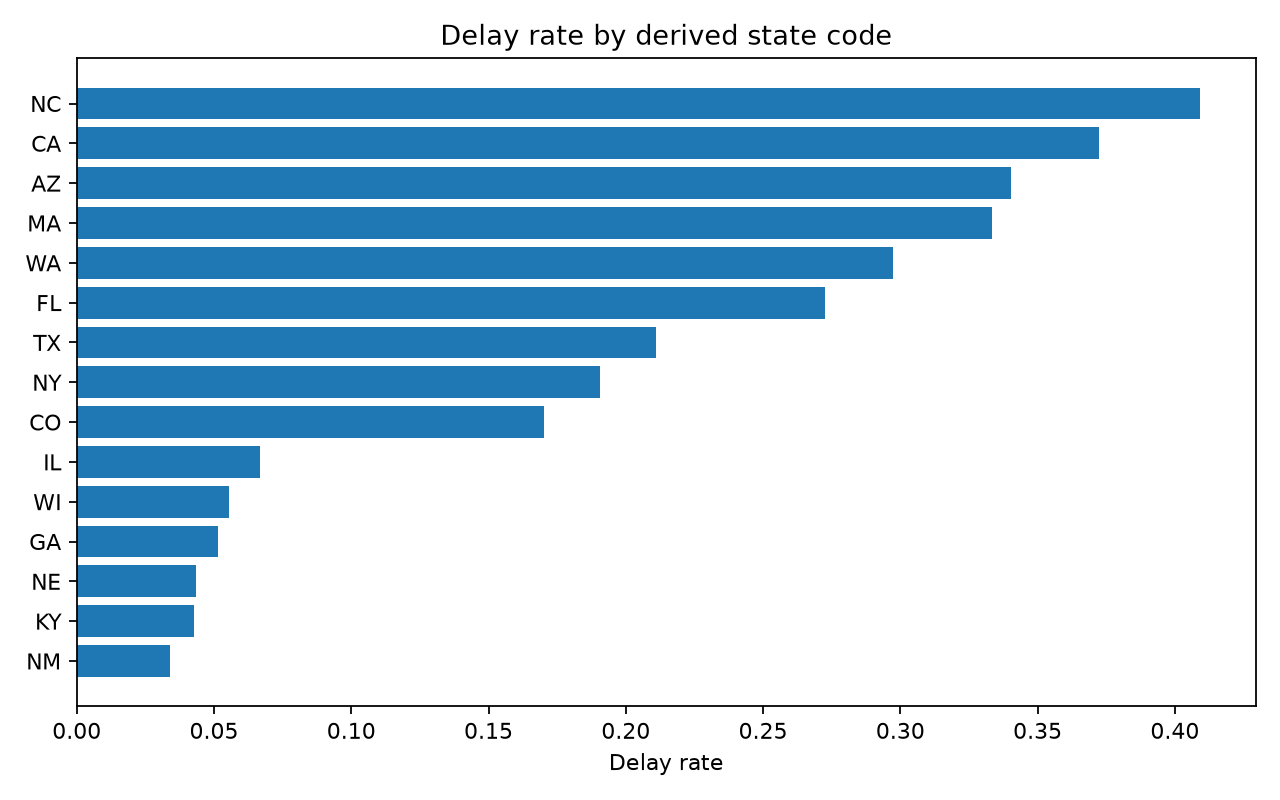

In [34]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "state_delay_rate_top15.png"))

## 7. Kiểm định giả thiết

**Vì sao bước này?**
- Làm gì: Tính toán hệ số Cramér's V và P-value (Chi-square test) để đo mức độ tương quan giữa các biến phân loại (traffic, distance, payment...) và nhãn `is_delayed`.
- Vì sao: Để biết biến nào THỰC SỰ có ảnh hưởng (đóng góp vào việc sinh ra nhãn trễ) một cách có ý nghĩa thống kê, loại bỏ nhiễu ngẫu nhiên.
  - **Chi-square (p-value)** trả lời: "Có mối liên hệ hay không?".
  - **Cramér's V** trả lời: "Mối liên hệ đó mạnh cỡ nào?" (0 là không, 1 là hoàn hảo).
- Kỹ thuật: Chi-square Test of Independence, Cramér's V.
- Bằng chứng dẫn tới: Cần bằng chứng toán học (thay vì chỉ nhìn biểu đồ) để quyết định chọn features nào đưa vào mô hình Logistic Regression sau này.

In [35]:
hypothesis_tests(df).round(6)

,variable,test,rows,chi2,dof,p_value,cramers_v,min_expected,significant_at_0_05,interpretation
4,traffic_level,chi-square independence vs is_delayed,3,265.676749,2,0.000000,0.514411,58.147410,True,Evidence of association with delay
3,pizza_type,chi-square independence vs is_delayed,12,186.022262,11,0.000000,0.430443,0.418327,True,Evidence of association with delay
0,payment_method,chi-square independence vs is_delayed,6,176.028340,5,0.000000,0.418721,4.810757,True,Evidence of association with delay
8,complexity_band,chi-square independence vs is_delayed,4,151.234790,3,0.000000,0.388114,42.669323,True,Evidence of association with delay
2,pizza_size,chi-square independence vs is_delayed,4,148.199282,3,0.000000,0.384199,27.609562,True,Evidence of association with delay
6,location_top12,chi-square independence vs is_delayed,13,142.016354,12,0.000000,0.376099,7.739044,True,Evidence of association with delay
5,restaurant_name,chi-square independence vs is_delayed,5,18.187573,4,0.001134,0.134592,40.577689,True,Evidence of association with delay
7,time_segment,chi-square independence vs is_delayed,3,14.442731,2,0.000731,0.119938,0.627490,True,Evidence of association with delay
1,payment_category,chi-square independence vs is_delayed,2,0.947863,1,0.330264,0.030726,52.081673,False,No strong evidence of association with delay


**Cách đọc.** Chi-square kiểm tra biến categorical có độc lập với
`is_delayed` hay không. `p < 0.05` = có bằng chứng liên hệ. Cột
`cramers_v` cho biết **độ mạnh**: traffic_level cao nhất (liên hệ vừa/
mạnh), kế đến pizza_type/payment/complexity; `payment_category` không
đáng kể.

**Insight.** p-value nhỏ + Cramér's V vừa của traffic/distance khớp với
bảng delay-rate ở mục 3. Nhưng vì dữ liệu có artifact, đây là bằng chứng
*liên hệ* để ưu tiên phân tích/dashboard, **không** phải quan hệ nhân quả.

## 8. Clustering và association rules

**Vì sao bước này?**
- Làm gì: Chạy thuật toán K-Means để gom nhóm dữ liệu (Clustering), đo chất lượng bằng Silhouette score. Sau đó khai thác luật kết hợp (Association Rules).
- Vì sao: 
  - **K-Means**: Dùng các feature không rò rỉ (distance_km, pizza_size_score, order_hour) để xem khách hàng tự nhiên chia thành các nhóm nào (ví dụ: nhóm chuyên gọi khuya, nhóm gọi gần...). Chọn K qua **Silhouette score** (đo lường độ "sắc nét" của cụm: trong cùng cụm thì giống nhau, giữa các cụm thì khác nhau).
  - **Association Rules**: Để tìm ra các tổ hợp điều kiện cùng xuất hiện dẫn đến rễ. Các ngưỡng binning (ví dụ binning distance_km thành `distance_band`) giúp quy dữ liệu liên tục về dạng rời rạc (itemset) để Apriori chạy được.
  - **Support**: Tần suất xuất hiện chung (A và B cùng xảy ra bao nhiêu lần).
  - **Confidence**: Xác suất trễ khi biết điều kiện A đã xảy ra.
  - **Lift**: Tỷ lệ giữa Confidence và tỷ lệ trễ chung (>1 nghĩa là điều kiện A làm TĂNG nguy cơ trễ).
- Kỹ thuật: K-Means Clustering, Silhouette Analysis, Apriori Algorithm (Association Rules).
- Bằng chứng dẫn tới: Mô hình supervised (LogReg) cho thấy distance và traffic quan trọng. Unsupervised learning (Clustering/Apriori) tái xác nhận điều này một cách độc lập khi nhóm có distance/traffic cao lại chính là nhóm có delay rate cao nhất.

In [36]:
pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "kmeans_silhouette.csv").round(4)

,k,silhouette
0,2,0.2274
1,3,0.1754
2,4,0.2021
3,5,0.2161
4,6,0.2021
5,7,0.2135


**Profile từng cụm** (cụm *nghĩa là gì*, không chỉ silhouette):

In [37]:
pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "kmeans_cluster_profile.csv").round(4)

,cluster,orders,order_share,delay_rate,avg_distance_km,avg_toppings,dominant_traffic,dominant_size
0,1,246,0.2450,0.6382,7.484,4.691,High,XL
1,0,448,0.4462,0.1161,4.856,3.491,Medium,Medium
2,2,259,0.2580,0.0039,2.983,1.931,Low,Medium
3,3,51,0.0508,0.0000,3.451,3.098,High,Medium


**Insight (cụm).** Các cụm tách chủ yếu theo distance/traffic: cụm có
`avg_distance_km` lớn và `dominant_traffic=High` chính là cụm
`delay_rate` cao. Điều này khớp mô hình supervised và xác nhận distance/
traffic là trục rủi ro chính, không phải brand hay payment.

In [38]:
association_rules_to_delay(df).head(15).round(4)

,antecedent,consequent,support,confidence,lift,matches
0,distance=high,delayed=True,0.1564,1.0000,4.7810,157
13,"distance=high, payment=Offline",delayed=True,0.0508,1.0000,4.7810,51
14,"distance=high, payment=Online",delayed=True,0.1056,1.0000,4.7810,106
15,"distance=high, peak=True",delayed=True,0.1554,1.0000,4.7810,156
16,"distance=high, size=Large",delayed=True,0.0707,1.0000,4.7810,71
17,"distance=high, size=XL",delayed=True,0.0837,1.0000,4.7810,84
18,"distance=high, toppings=high",delayed=True,0.1534,1.0000,4.7810,154
19,"distance=high, traffic=High",delayed=True,0.1524,1.0000,4.7810,153
20,"distance=high, weekend=False",delayed=True,0.1096,1.0000,4.7810,110
21,"distance=high, weekend=True",delayed=True,0.0468,1.0000,4.7810,47


**Insight.** K-Means và association rules dùng để khám phá nhóm điều
kiện thường đi với delayed. Chúng không thay thế mô hình supervised
và không tự động sinh quyết định điều phối.

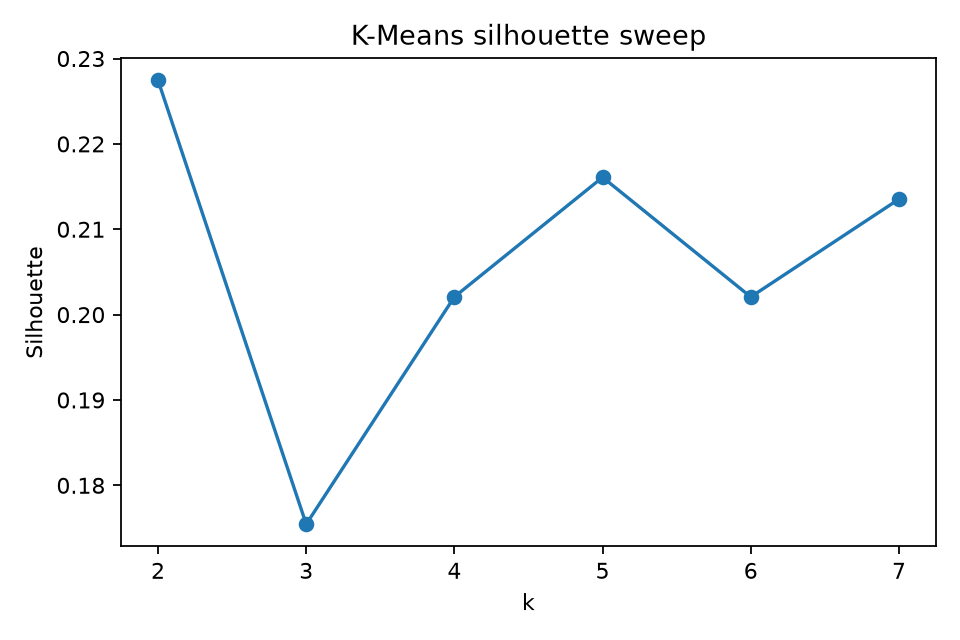

In [39]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "kmeans_silhouette.png"))

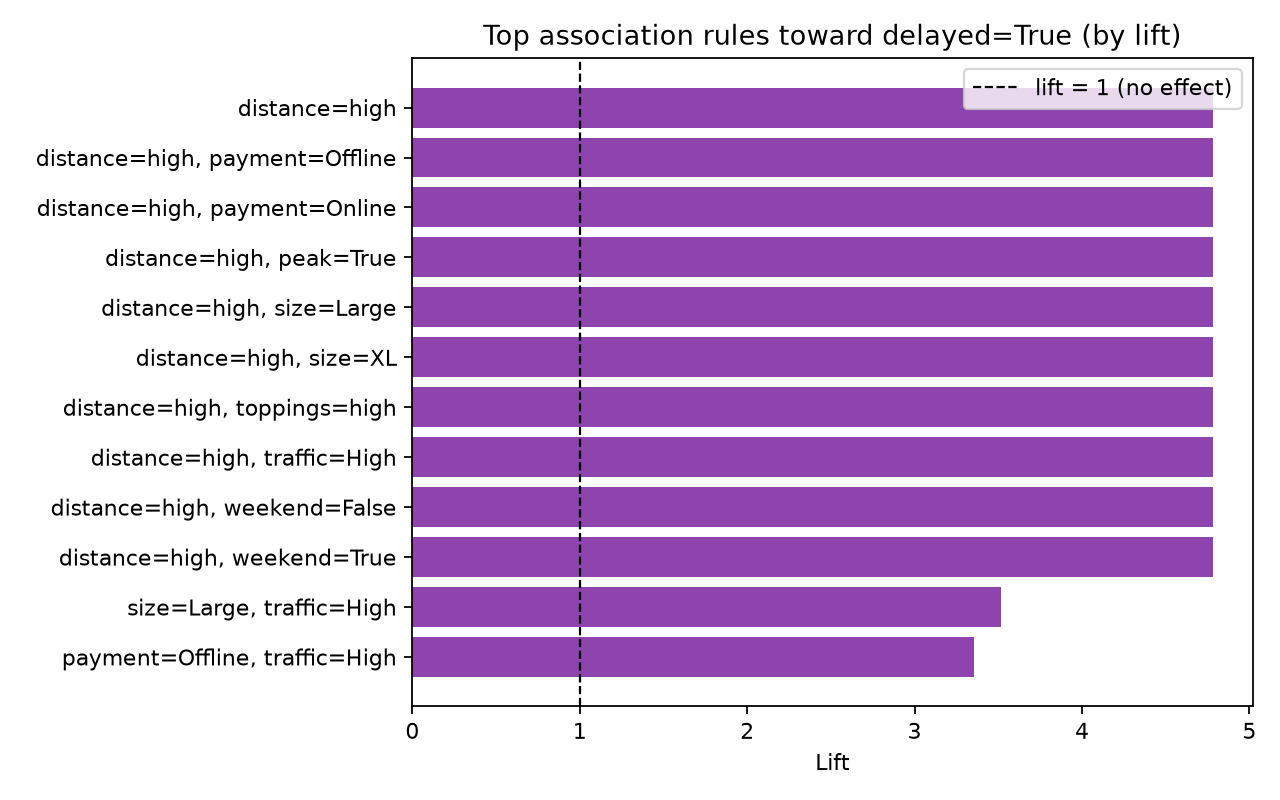

In [40]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "association_lift_top.png"))

## 9. Insight dẫn đến quyết định DSS

In [41]:
pd.DataFrame([
    {
        "question": "Bao nhiêu phút thì nhãn chuyển sang trễ?",
        "evidence": "On-time max=30, delayed min=35; threshold rules mismatch=0.",
        "decision": "Chặn duration/delay khỏi feature; trình bày ngưỡng là suy luận từ nhãn.",
    },
    {
        "question": "Yếu tố nào cần đưa vào Risk Score?",
        "evidence": "Traffic, distance và complexity làm delay rate thay đổi rõ.",
        "decision": "Dùng traffic/distance/peak/complexity trong Risk Score.",
    },
    {
        "question": "Món nào được yêu thích?",
        "evidence": "Medium nhiều nhất; Non-Veg nhiều nhất; combo type-size có chênh lệch lớn.",
        "decision": "Đưa size/type mix vào dashboard, Power BI và recommendation rule.",
    },
    {
        "question": "Có nên phân tích theo brand/location/state?",
        "evidence": "Brand/location/state có mix và delay rate khác nhau nhưng nhiều artifact/small sample.",
        "decision": "Báo cáo mô tả kèm caveat, không kết luận chất lượng thật của hãng/khu vực.",
    },
    {
        "question": "Metric modeling nên chọn gì?",
        "evidence": "Delayed là lớp thiểu số khoảng 21%.",
        "decision": "Dùng F2/Recall cùng Balanced Accuracy/MCC, không dùng Accuracy đơn lẻ.",
    },
])

,question,evidence,decision
0,Bao nhiêu phút thì nhãn chuyển sang trễ?,"On-time max=30, delayed min=35; threshold rule...",Chặn duration/delay khỏi feature; trình bày ng...
1,Yếu tố nào cần đưa vào Risk Score?,"Traffic, distance và complexity làm delay rate...",Dùng traffic/distance/peak/complexity trong Ri...
2,Món nào được yêu thích?,Medium nhiều nhất; Non-Veg nhiều nhất; combo t...,"Đưa size/type mix vào dashboard, Power BI và r..."
3,Có nên phân tích theo brand/location/state?,Brand/location/state có mix và delay rate khác...,"Báo cáo mô tả kèm caveat, không kết luận chất ..."
4,Metric modeling nên chọn gì?,Delayed là lớp thiểu số khoảng 21%.,"Dùng F2/Recall cùng Balanced Accuracy/MCC, khô..."


## 10. Xác nhận artifact

Toàn bộ CSV/figure đã được sinh **một lần** ở Bước 0 (`build_eda_artifacts`).
Cell dưới chỉ liệt kê để xác nhận, không tính lại — tách bạch giữa *sinh
artifact* (một nơi) và *trình bày* (các mục trên).

In [42]:
import os
figs = sorted(f for f in os.listdir(PROJECT_ROOT / "reports" / "figures") if f.endswith(".png"))
{"n_figures": len(figs), "examples": figs[:6]}

{'n_figures': 42,
 'examples': ['association_lift_top.png',
  'brand_delay_rate_homogeneity.png',
  'complexity_distribution.png',
  'confusion_matrix_test.png',
  'correlation_heatmap.png',
  'delay_distribution.png']}